In [ ]:
data = {
    "review": [
        "Claim process was very slow",
        "Customer support was helpful",
        "Billing issue not resolved",
        "Great experience with services",
        "Long waiting time for claim approval",
        "Very satisfied with customer care",
        "Poor response from support team",
        "Quick claim settlement process",
        "Had trouble with policy details",
        "Excellent support and guidance",
        "Claim got rejected without reason",
        "Happy with the smooth process",
        "Too much delay in reimbursement",
        "Support team resolved my issue quickly",
        "Unclear billing statements",
        "Very professional service",
        "Bad experience with claim handling",
        "Good communication from team",
        "Facing issues with login and portal",
        "Very helpful and polite staff",
        "Claim process is confusing",
        "Got my claim approved quickly",
        "Customer care is not responsive",
        "Excellent healthcare support",
        "Delay in customer response",
        "Satisfied with claim resolution",
        "Too many documentation requirements",
        "Great experience overall",
        "Issues with reimbursement process",
        "Friendly and supportive staff"
    ]
}

IMPORTING AND USING PANDAS TO CONVERT DATA INTO DATAFRAME

In [ ]:
import pandas as pd

df = pd.DataFrame(data)
df.head()

,review
0,Claim process was very slow
1,Customer support was helpful
2,Billing issue not resolved
3,Great experience with services
4,Long waiting time for claim approval


USING TEXTBLOB NLP LIBRARY TO GENERATE SENTIMENT POLARITY SCORES (-1,0,+1)

In [ ]:
from textblob import TextBlob

df["sentiment_score"] = df["review"].apply(lambda x: TextBlob(x).sentiment.polarity)

df.head()

,review,sentiment_score
0,Claim process was very slow,-0.39
1,Customer support was helpful,0.00
2,Billing issue not resolved,0.00
3,Great experience with services,0.80
4,Long waiting time for claim approval,-0.05


BASED ON POLARITY SCORES, CLASSIFY REVIEW INTO POSITIVE, NEUTRAL & NEGATIVE

In [ ]:
def classify(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["sentiment_score"].apply(classify)

df.head()

,review,sentiment_score,sentiment
0,Claim process was very slow,-0.39,Negative
1,Customer support was helpful,0.00,Neutral
2,Billing issue not resolved,0.00,Neutral
3,Great experience with services,0.80,Positive
4,Long waiting time for claim approval,-0.05,Negative


ANALYZE THE DISTRIBUTION OF SENTIMENTS

In [ ]:
df["sentiment"].value_counts()

,count
sentiment,
Positive,16
Neutral,8
Negative,6


VISUALIZE THE DISTRIBUTION OF SENTIMENTS USING SEABORN

/tmp/ipykernel_6500/4021732097.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="sentiment", data=df, palette="deep").set(title="Customer Sentiment Analysis")


[Text(0.5, 1.0, 'Customer Sentiment Analysis')]

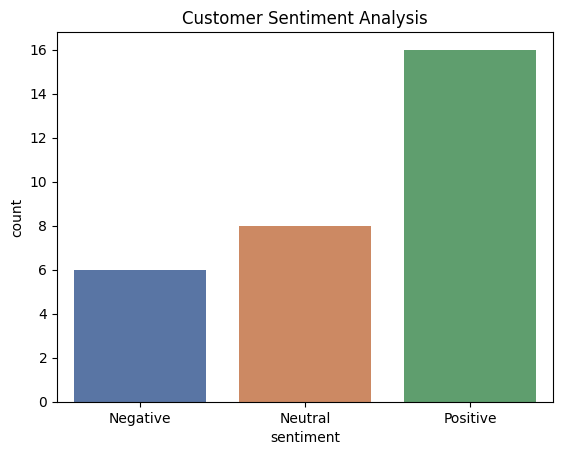

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="sentiment", data=df, palette="deep").set(title="Customer Sentiment Analysis")
#plt.title("Customer Sentiment Analysis")
#plt.show()

CHECKING WHICH NEGATIVE SEGMENT NEEDS BUSINESS ATTENTION

In [ ]:
Negative_sentiments = df[df["sentiment"] == "Negative"]
Negative_sentiments

,review,sentiment_score,sentiment
0,Claim process was very slow,-0.39,Negative
4,Long waiting time for claim approval,-0.05,Negative
6,Poor response from support team,-0.40,Negative
8,Had trouble with policy details,-0.20,Negative
16,Bad experience with claim handling,-0.70,Negative
20,Claim process is confusing,-0.30,Negative


So it's 'CLAIM' that needs Business Attention!